# Topic 15: FrozenLake and Taxi (Stochasticity and Scale)

Same Q-learning agent, two new Toy Text environments. **FrozenLake** adds stochastic dynamics
(slippery ice) and a sparse reward; **Taxi** adds scale (500 states) and a shaped multi-step
task. Only the `gym.make` string and a couple of hyperparameters change.

In [1]:
def train(env_name, episodes, alpha=0.5, gamma=0.99, eps_min=0.0, decay=None,
          make_kwargs=None, cap=-10**9, seed=0, metric="return"):
    import gymnasium as gym, numpy as np, random
    random.seed(seed); np.random.seed(seed)
    env = gym.make(env_name, **(make_kwargs or {}))
    if decay is None: decay = episodes * 0.5
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    hist = np.empty(episodes)
    for ep in range(episodes):
        eps = max(eps_min, 1.0 - ep/decay)
        s,_ = env.reset(seed=seed*10000+ep); done=False; tot=0.0; last_r=0.0; t=0
        while not done and t < 200:
            a = env.action_space.sample() if random.random()<eps else int(np.argmax(Q[s]))
            s2,r,term,trunc,_ = env.step(a); done=term or trunc; tot+=r; last_r=r
            target = r + (0.0 if done else gamma*np.max(Q[s2]))
            Q[s,a] += alpha*(target - Q[s,a]); s=s2; t+=1
        hist[ep] = max(tot, cap) if metric=="return" else last_r
    env.close()
    return hist, Q

## 1. FrozenLake: stochastic ice, sparse reward

Reward is 0 except +1 at the Goal; with `is_slippery=True` the intended move works only 1/3 of the time. We track the goal-reaching rate (whether each episode reached the Goal), and compare slippery vs deterministic.

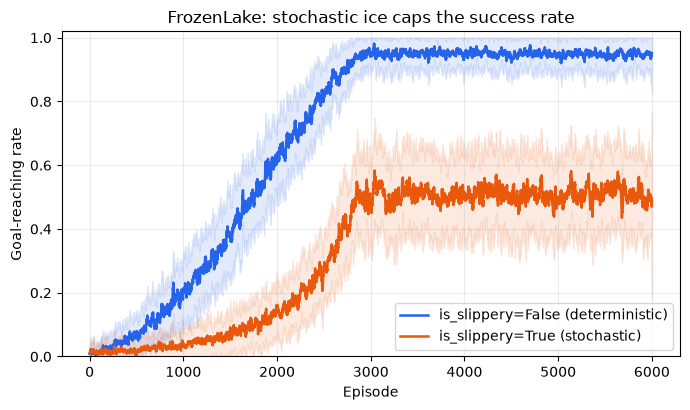

In [2]:
import numpy as np, matplotlib.pyplot as plt
def smooth(x,k=15):
    pad=np.concatenate([np.full(k//2,x[0]),x,np.full(k//2,x[-1])]); return np.convolve(pad,np.ones(k)/k,mode="valid")[:len(x)]
def fmany(slippery, episodes=6000, seeds=40):
    R=np.stack([smooth(train("FrozenLake-v1", episodes, alpha=0.1, gamma=0.99, eps_min=0.05,
                             make_kwargs={"is_slippery":slippery}, metric="success", seed=i)[0]) for i in range(seeds)])
    return R.mean(0), R.std(0)
EP=6000; x=np.arange(1,EP+1)
plt.figure(figsize=(7,4.2))
for slip,col,lab in [(False,"#2563eb","is_slippery=False (deterministic)"),(True,"#ea580c","is_slippery=True (stochastic)")]:
    m,s=fmany(slip); plt.plot(x,m,color=col,lw=1.8,label=lab); plt.fill_between(x,np.clip(m-s,0,1),np.clip(m+s,0,1),color=col,alpha=0.13)
plt.ylim(0,1.02); plt.xlabel("Episode"); plt.ylabel("Goal-reaching rate")
plt.title("FrozenLake: stochastic ice caps the success rate"); plt.legend(loc="lower right"); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

Deterministic ice rises to ~100%; slippery ice plateaus near ~50%, even the optimal policy sometimes slides into a hole. The ceiling is set by the environment, not the agent.

## 2. Taxi: 500 states, shaped reward

State packs taxi position x passenger location x destination into one integer (500). Reward: -1 per step, +20 correct drop-off, -10 illegal pick-up/drop-off. Same loop, just larger and run longer.

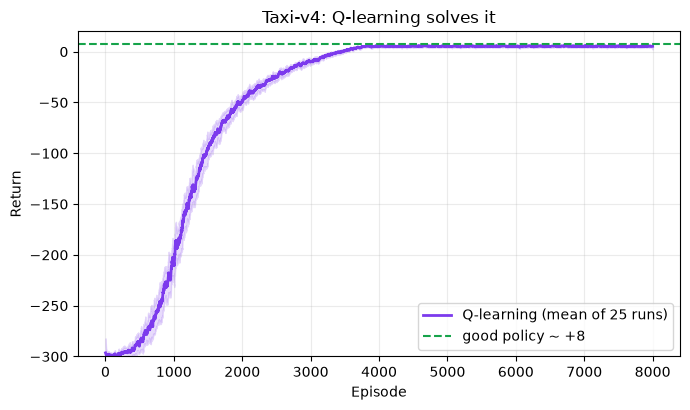

Taxi final return: 5.3


In [3]:
def tmany(episodes=8000, seeds=25):
    R=np.stack([smooth(train("Taxi-v4", episodes, alpha=0.1, gamma=0.99, eps_min=0.05, cap=-300, seed=i)[0],25) for i in range(seeds)])
    return R.mean(0), R.std(0)
EPT=8000; xt=np.arange(1,EPT+1)
m,s=tmany()
plt.figure(figsize=(7,4.2))
plt.plot(xt,m,color="#7c3aed",lw=2,label="Q-learning (mean of 25 runs)")
plt.fill_between(xt,m-s,m+s,color="#7c3aed",alpha=0.18)
plt.axhline(8,color="#16a34a",ls="--",label="good policy ~ +8"); plt.ylim(-300,20)
plt.xlabel("Episode"); plt.ylabel("Return"); plt.title("Taxi-v4: Q-learning solves it")
plt.legend(loc="lower right"); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()
print("Taxi final return:", round(m[-200:].mean(),1))

## Summary
| | CliffWalking | FrozenLake | Taxi |
|---|---|---|---|
| states | 48 | 16 | 500 |
| dynamics | deterministic | **stochastic** | deterministic |
| reward | -1, -100 | **sparse** +1 | shaped -1/+20/-10 |

One agent, three problems, only the environment changed. Continuous-observation environments wait for **DQN (Topic 18)**.